# 02 — User Analysis
Per-participant activity, sentiment timeline and heatmap.

> `user_analyzer.py` is not yet implemented — results are built from
> synthetic data that mirrors the expected output shape.

## 0 · Setup

In [7]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
print("Ready.")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## 1 · Build synthetic per-user data

In [ ]:
# Synthetic authors — no real data
AUTHORS = ["Aminata", "Moussa", "Fatou", "Ibrahima", "Mariama"]
rng = np.random.default_rng(0)

timestamps = pd.date_range("2024-01-01 07:00", periods=200, freq="2h")
df = pd.DataFrame({
    "timestamp"       : rng.choice(timestamps, size=200),
    "author"          : rng.choice(AUTHORS, size=200),
    "message"         : [f"synthetic message {i}" for i in range(200)],
    "cleaned_message" : [f"clean token{i} word{i}" for i in range(200)],
    "topic_label"     : rng.choice(["Travail", "Organisation", "Social"], size=200),
    "sentiment_score" : rng.uniform(-1, 1, size=200).round(2),
    "sentiment_label" : rng.choice(["positive", "negative", "neutral"], size=200),
})
df = df.sort_values("timestamp").reset_index(drop=True)

# Per-user summary dict (mirrors expected UserAnalyzer output)
users = {}
for author in AUTHORS:
    sub = df[df["author"] == author]
    users[author] = {
        "message_count"      : len(sub),
        "media_count"        : int(rng.integers(0, 5)),
        "avg_message_length" : round(float(rng.uniform(10, 50)), 1),
        "active_days"        : int(sub["timestamp"].dt.date.nunique()),
        "top_topics"         : sub["topic_label"].value_counts().head(2).index.tolist(),
        "sentiment_mean"     : round(float(sub["sentiment_score"].mean()), 2),
    }

print("Synthetic dataset: {} messages, {} authors".format(len(df), len(AUTHORS)))

Synthetic dataset: 200 messages, 5 authors


## 2 · `user.summary()` — per-participant profile

In [ ]:
def print_summary(name: str) -> None:
    """Print a profile card for one participant."""
    u = users[name]
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Messages       : {u['message_count']}")
    print(f"  Media shared   : {u['media_count']}")
    print(f"  Avg length     : {u['avg_message_length']} chars")
    print(f"  Active days    : {u['active_days']}")
    print(f"  Top topics     : {', '.join(u['top_topics'])}")
    print(f"  Sentiment mean : {u['sentiment_mean']}")
    print()

for author in AUTHORS:
    print_summary(author)

  Aminata
  Messages       : 39
  Media shared   : 3
  Avg length     : 38.8 chars
  Active days    : 16
  Top topics     : Travail, Organisation
  Sentiment mean : 0.05

  Moussa
  Messages       : 33
  Media shared   : 0
  Avg length     : 37.1 chars
  Active days    : 16
  Top topics     : Travail, Social
  Sentiment mean : -0.06

  Fatou
  Messages       : 45
  Media shared   : 0
  Avg length     : 37.5 chars
  Active days    : 16
  Top topics     : Travail, Organisation
  Sentiment mean : 0.06

  Ibrahima
  Messages       : 36
  Media shared   : 3
  Avg length     : 33.5 chars
  Active days    : 15
  Top topics     : Social, Organisation
  Sentiment mean : 0.05

  Mariama
  Messages       : 47
  Media shared   : 1
  Avg length     : 36.8 chars
  Active days    : 16
  Top topics     : Social, Organisation
  Sentiment mean : 0.05



## 3 · Activity heatmap (hour × weekday)

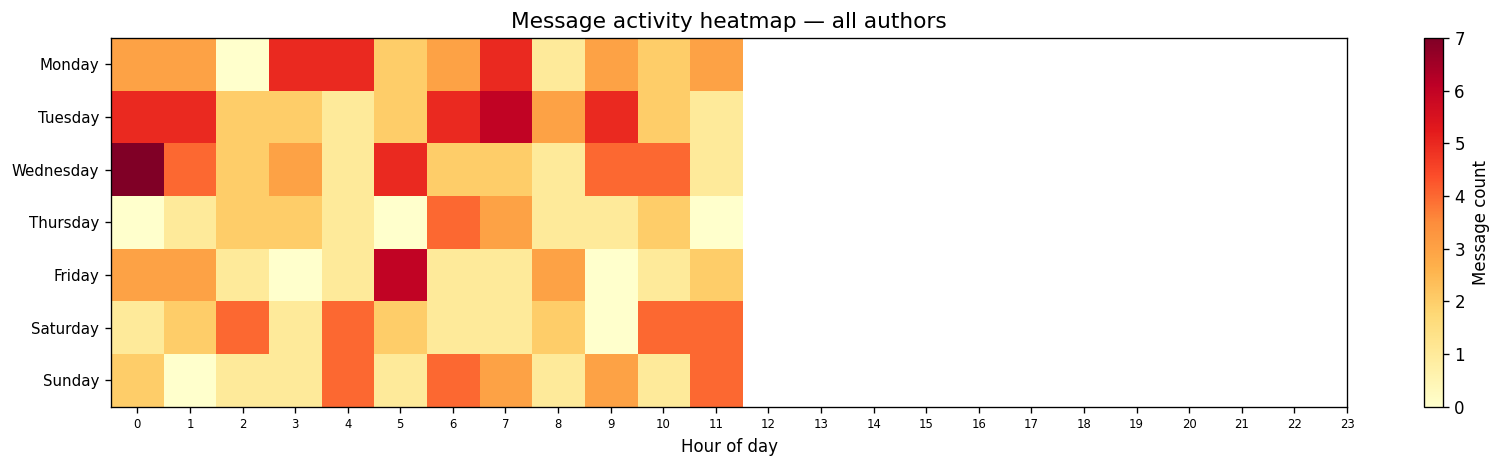

In [ ]:
df["hour"]    = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()

WEEKDAYS = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heatmap = (
    df.groupby(["weekday", "hour"])
      .size()
      .unstack(fill_value=0)
      .reindex(WEEKDAYS)
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heatmap.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=7)
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAYS, fontsize=9)
ax.set_xlabel("Hour of day")
ax.set_title("Message activity heatmap — all authors", fontsize=13)
plt.colorbar(im, ax=ax, label="Message count")
plt.tight_layout()
plt.show()

## 4 · Sentiment timeline per user

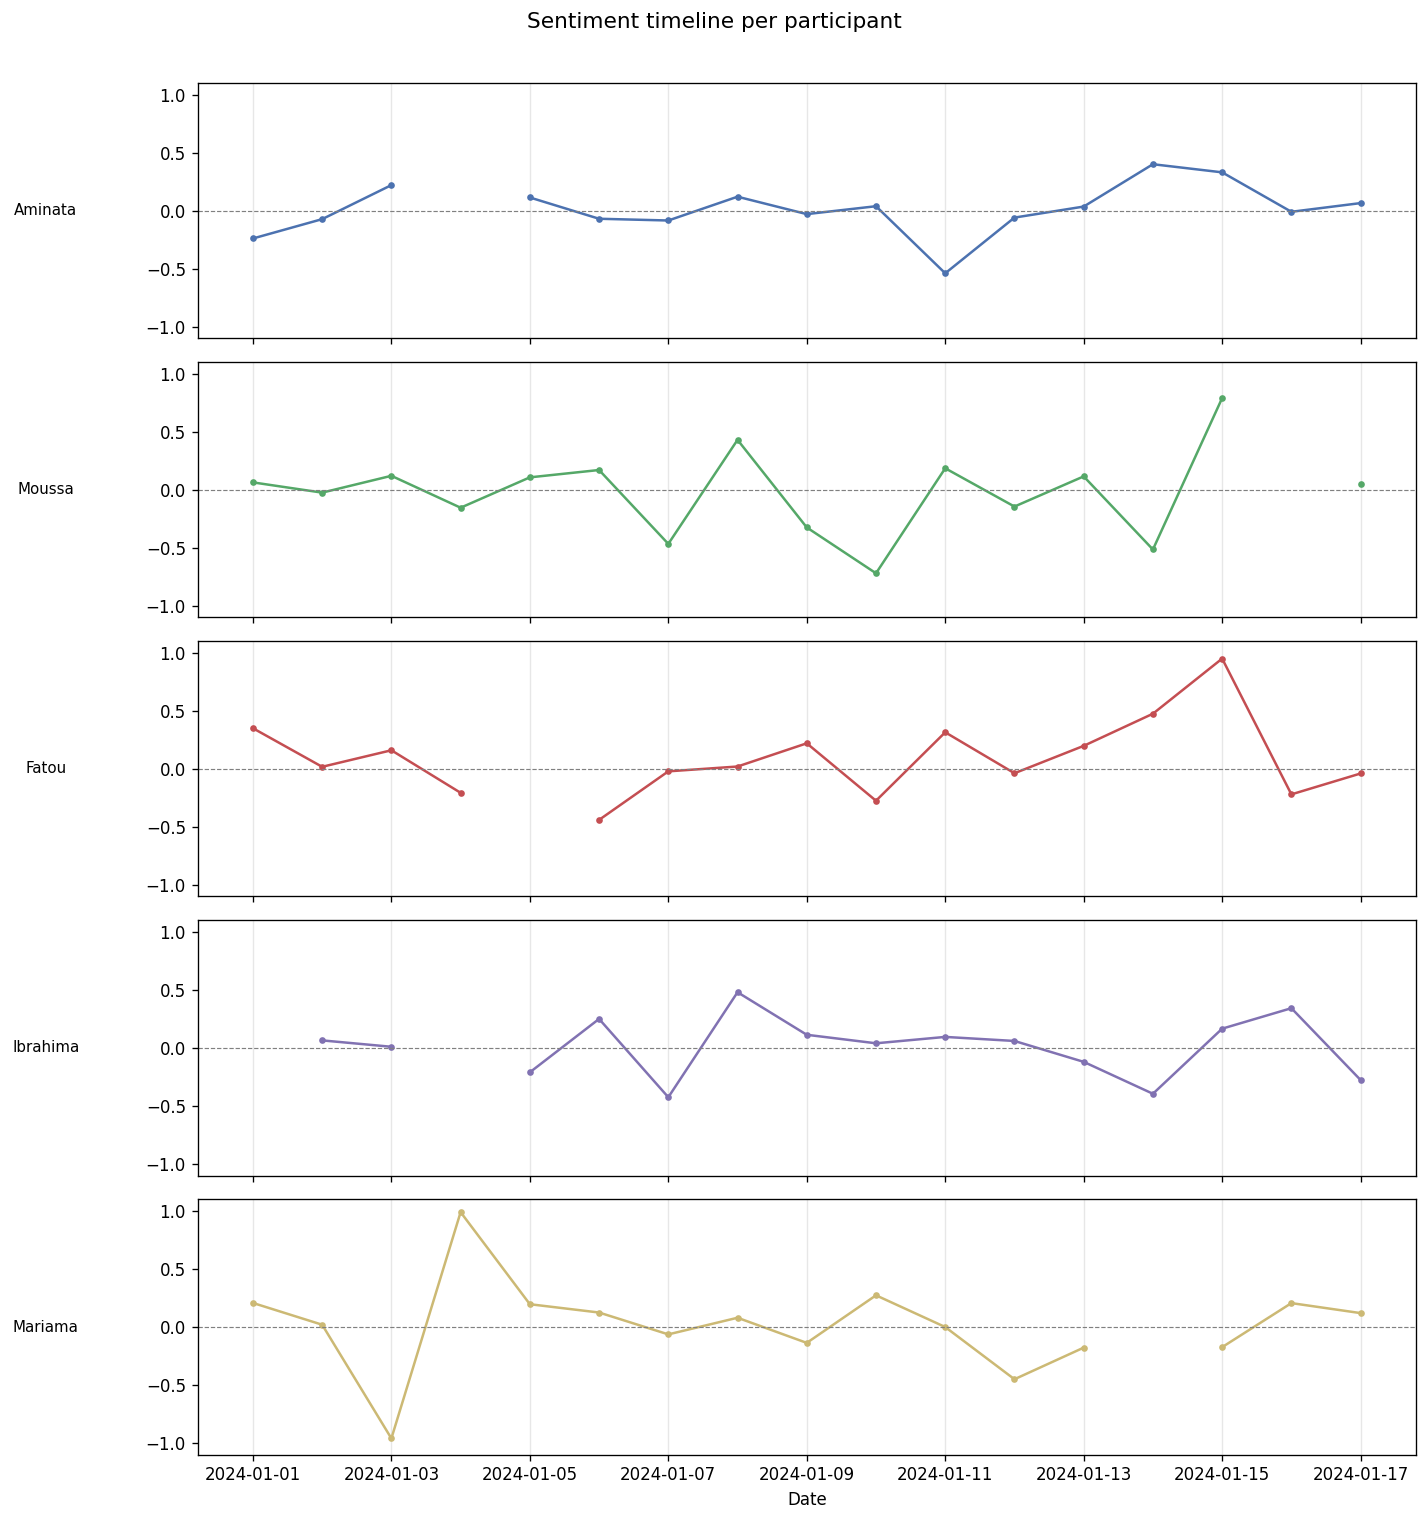

In [ ]:
fig, axes = plt.subplots(len(AUTHORS), 1, figsize=(12, 2.5 * len(AUTHORS)),
                         sharex=True)
colors = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"]

for ax, author, color in zip(axes, AUTHORS, colors):
    sub = df[df["author"] == author].set_index("timestamp")["sentiment_score"]
    sub_daily = sub.resample("D").mean()
    ax.plot(sub_daily.index, sub_daily.values, color=color, linewidth=1.5, marker="o", markersize=3)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
    ax.set_ylabel(author, fontsize=9, rotation=0, labelpad=60, va="center")
    ax.set_ylim(-1.1, 1.1)
    ax.grid(axis="x", alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Sentiment timeline per participant", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5 · Message count per author

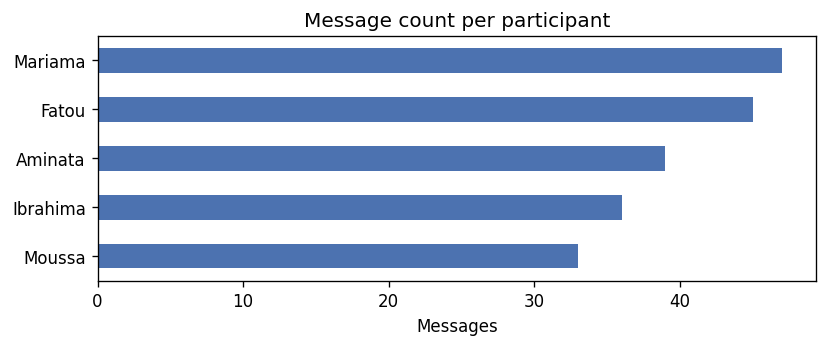

In [ ]:
counts = pd.Series({a: u["message_count"] for a, u in users.items()}).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3))
counts.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Message count per participant", fontsize=12)
ax.set_xlabel("Messages")
plt.tight_layout()
plt.show()